In [1]:
# ============================================================
# 05 — N-GRAM EVALUATION, VISUALIZATION & EXPLAINABILITY
# ============================================================

import os
import json
import math
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ============================================================
# PROJECT CONFIGURATION
# ============================================================

BASE_DIR = Path('/content/drive/MyDrive/NLP_Research_Project')

RESULTS_DIR = BASE_DIR / 'results'

METRICS_DIR = RESULTS_DIR / 'metrics'
PREDICTIONS_DIR = RESULTS_DIR / 'predictions'
CM_DIR = RESULTS_DIR / 'confusion_matrices'

# Dedicated output directory for YOUR analysis
EVAL_DIR = RESULTS_DIR / 'ngram_evaluation'

FIGURES_DIR = EVAL_DIR / 'figures'
TABLES_DIR = EVAL_DIR / 'tables'
ERROR_DIR = EVAL_DIR / 'error_analysis'
EXPLAIN_DIR = EVAL_DIR / 'explainability'

for directory in [
    EVAL_DIR,
    FIGURES_DIR,
    TABLES_DIR,
    ERROR_DIR,
    EXPLAIN_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Evaluation directory:")
print(EVAL_DIR)

Evaluation directory:
/content/drive/MyDrive/NLP_Research_Project/results/ngram_evaluation


In [4]:
required_files = {
    # Validation
    "Validation N-gram comparison":
        METRICS_DIR / "ngram_validation_comparison.csv",

    "Validation unigram predictions":
        PREDICTIONS_DIR / "validation_unigram_predictions.csv",

    "Validation bigram predictions":
        PREDICTIONS_DIR / "validation_bigram_predictions.csv",

    "Validation trigram predictions":
        PREDICTIONS_DIR / "validation_trigram_predictions.csv",

    # Per-class
    "Validation per-class F1 comparison":
        METRICS_DIR / "validation_per_class_f1_comparison.csv",

    # Final test
    "Test bigram predictions":
        PREDICTIONS_DIR / "test_bigram_predictions.csv",

    "Test bigram metrics":
        METRICS_DIR / "test_bigram_metrics.csv",

    "Test bigram per-class":
        METRICS_DIR / "test_bigram_per_class.csv",

    # Confusion matrices
    "Validation bigram confusion matrix":
        CM_DIR / "validation_bigram_confusion_matrix.csv",

    "Validation normalized confusion matrix":
        CM_DIR / "validation_bigram_confusion_matrix_normalized.csv",

    "Test bigram confusion matrix":
        CM_DIR / "test_bigram_confusion_matrix.csv",

    "Test normalized confusion matrix":
        CM_DIR / "test_bigram_confusion_matrix_normalized.csv"
}

verification = []

for name, path in required_files.items():
    verification.append({
        "Artifact": name,
        "Exists": path.exists(),
        "Path": str(path)
    })

verification_df = pd.DataFrame(verification)

display(verification_df)

missing = verification_df.loc[
    ~verification_df["Exists"], "Artifact"
].tolist()

if missing:
    raise FileNotFoundError(
        f"The following expected artifacts are missing:\n{missing}"
    )

print("\nAll required N-gram results are available.")

,Artifact,Exists,Path
0,Validation N-gram comparison,True,/content/drive/MyDrive/NLP_Research_Project/re...
1,Validation unigram predictions,True,/content/drive/MyDrive/NLP_Research_Project/re...
2,Validation bigram predictions,True,/content/drive/MyDrive/NLP_Research_Project/re...
3,Validation trigram predictions,True,/content/drive/MyDrive/NLP_Research_Project/re...
4,Validation per-class F1 comparison,True,/content/drive/MyDrive/NLP_Research_Project/re...
5,Test bigram predictions,True,/content/drive/MyDrive/NLP_Research_Project/re...
6,Test bigram metrics,True,/content/drive/MyDrive/NLP_Research_Project/re...
7,Test bigram per-class,True,/content/drive/MyDrive/NLP_Research_Project/re...
8,Validation bigram confusion matrix,True,/content/drive/MyDrive/NLP_Research_Project/re...
9,Validation normalized confusion matrix,True,/content/drive/MyDrive/NLP_Research_Project/re...



All required N-gram results are available.


In [5]:
# ============================================================
# LOAD EXISTING PREDICTIONS
# ============================================================

val_unigram = pd.read_csv(
    PREDICTIONS_DIR / "validation_unigram_predictions.csv"
)

val_bigram = pd.read_csv(
    PREDICTIONS_DIR / "validation_bigram_predictions.csv"
)

val_trigram = pd.read_csv(
    PREDICTIONS_DIR / "validation_trigram_predictions.csv"
)

test_bigram = pd.read_csv(
    PREDICTIONS_DIR / "test_bigram_predictions.csv"
)

# Existing metric tables
validation_results = pd.read_csv(
    METRICS_DIR / "ngram_validation_comparison.csv"
)

test_metrics = pd.read_csv(
    METRICS_DIR / "test_bigram_metrics.csv"
)

test_per_class = pd.read_csv(
    METRICS_DIR / "test_bigram_per_class.csv"
)

per_class_comparison = pd.read_csv(
    METRICS_DIR / "validation_per_class_f1_comparison.csv"
)

print("Validation unigram:", val_unigram.shape)
print("Validation bigram:", val_bigram.shape)
print("Validation trigram:", val_trigram.shape)
print("Test bigram:", test_bigram.shape)

Validation unigram: (1377, 11)
Validation bigram: (1377, 11)
Validation trigram: (1377, 11)
Test bigram: (1377, 11)


In [6]:
SPLITS_DIR = BASE_DIR / 'data' / 'splits'

VAL_PATH = SPLITS_DIR / 'validation.csv'
TEST_PATH = SPLITS_DIR / 'test.csv'

val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

TEXT_COLUMN = "text"
ID_COLUMN = "id"
LABEL_COLUMN = "label"

print("Validation dataset:", val_df.shape)
print("Test dataset:", test_df.shape)

Validation dataset: (1377, 4)
Test dataset: (1377, 4)


In [7]:
# ============================================================
# SANITY CHECKS
# ============================================================

assert len(val_bigram) == len(val_df)
assert len(test_bigram) == len(test_df)

assert val_bigram["id"].tolist() == val_df["id"].tolist()
assert test_bigram["id"].tolist() == test_df["id"].tolist()

assert val_bigram["true_label"].tolist() == \
       val_df[LABEL_COLUMN].astype(int).tolist()

assert test_bigram["true_label"].tolist() == \
       test_df[LABEL_COLUMN].astype(int).tolist()

print("Prediction-to-dataset alignment verified.")

Prediction-to-dataset alignment verified.


In [8]:
display(
    validation_results.style.format({
        "Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}",
        "Weighted F1": "{:.4f}",
        "Inference Time (s)": "{:.2f}"
    })
)

,Model,Order,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Inference Time (s)
0,Unigram,1,0.7691,0.3943,0.4335,0.3838,0.7841,0.86
1,Bigram,2,0.8526,0.6263,0.5633,0.5847,0.8519,3.24
2,Trigram,3,0.8475,0.6142,0.5397,0.5521,0.8438,7.47


In [9]:
validation_results.to_csv(
    TABLES_DIR / "ngram_order_performance.csv",
    index=False
)

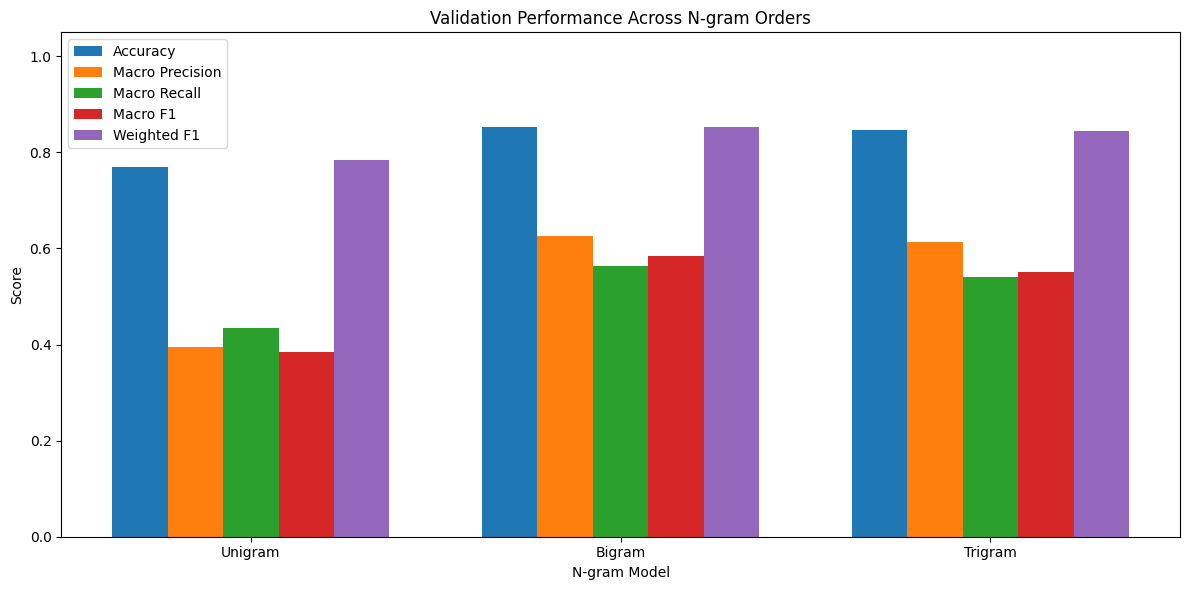

In [10]:
metrics_to_plot = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Weighted F1"
]

x = np.arange(len(validation_results))
width = 0.15

plt.figure(figsize=(12, 6))

for i, metric in enumerate(metrics_to_plot):
    plt.bar(
        x + (i - 2) * width,
        validation_results[metric],
        width,
        label=metric
    )

plt.xticks(
    x,
    validation_results["Model"]
)

plt.ylabel("Score")
plt.xlabel("N-gram Model")
plt.title("Validation Performance Across N-gram Orders")
plt.ylim(0, 1.05)
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "ngram_order_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

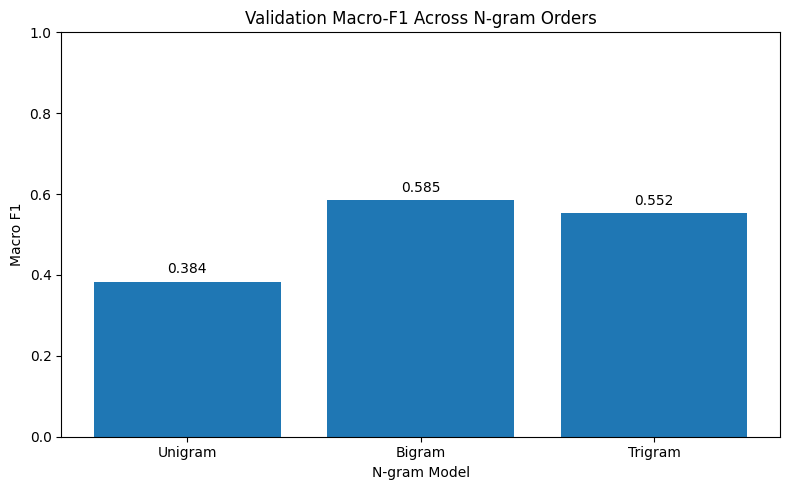

In [11]:
plt.figure(figsize=(8, 5))

plt.bar(
    validation_results["Model"],
    validation_results["Macro F1"]
)

plt.ylabel("Macro F1")
plt.xlabel("N-gram Model")
plt.title("Validation Macro-F1 Across N-gram Orders")
plt.ylim(0, 1)

for i, value in enumerate(validation_results["Macro F1"]):
    plt.text(
        i,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "ngram_macro_f1_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

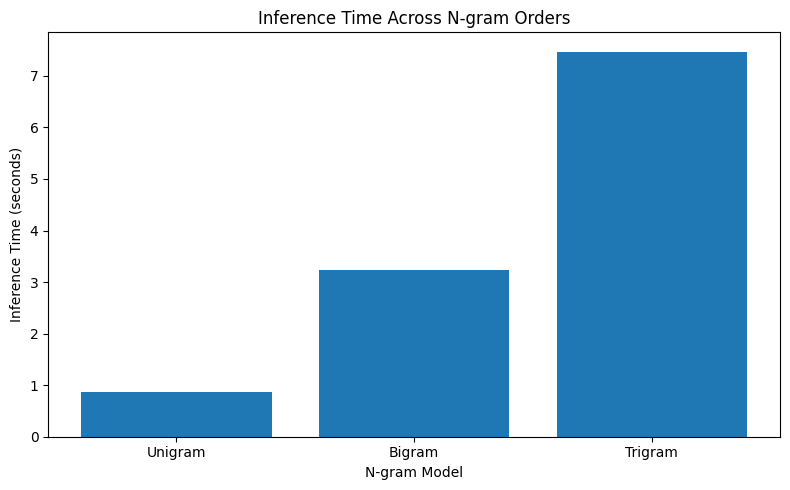

In [12]:
plt.figure(figsize=(8, 5))

plt.bar(
    validation_results["Model"],
    validation_results["Inference Time (s)"]
)

plt.xlabel("N-gram Model")
plt.ylabel("Inference Time (seconds)")
plt.title("Inference Time Across N-gram Orders")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "ngram_inference_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
display(
    per_class_comparison.style.format({
        "Unigram F1": "{:.4f}",
        "Bigram F1": "{:.4f}",
        "Trigram F1": "{:.4f}"
    })
)

,Class,Unigram F1,Bigram F1,Trigram F1
0,BI-RADS 0,0.5922,0.6543,0.6087
1,BI-RADS 1,0.1633,0.6333,0.5660
2,BI-RADS 2,0.8755,0.9250,0.9206
3,BI-RADS 3,0.3887,0.4803,0.4885
4,BI-RADS 4,0.4848,0.5429,0.5507
5,BI-RADS 5,0.0000,0.2857,0.2857
6,BI-RADS 6,0.1818,0.5714,0.4444


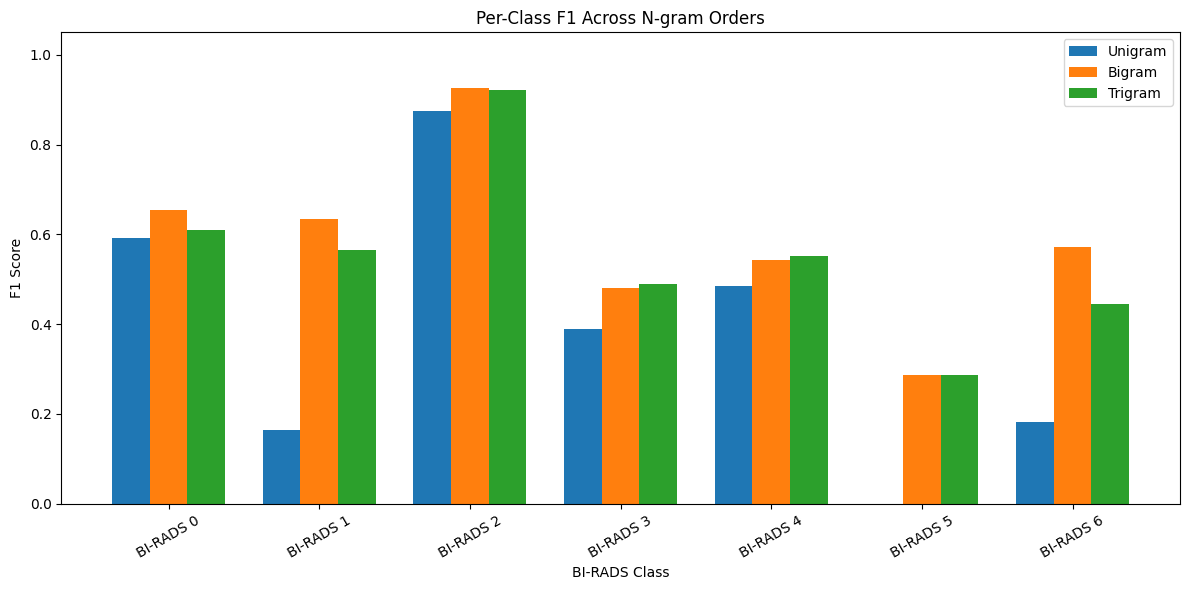

In [14]:
classes = per_class_comparison["Class"]

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(
    x - width,
    per_class_comparison["Unigram F1"],
    width,
    label="Unigram"
)

plt.bar(
    x,
    per_class_comparison["Bigram F1"],
    width,
    label="Bigram"
)

plt.bar(
    x + width,
    per_class_comparison["Trigram F1"],
    width,
    label="Trigram"
)

plt.xticks(x, classes, rotation=30)
plt.ylabel("F1 Score")
plt.xlabel("BI-RADS Class")
plt.title("Per-Class F1 Across N-gram Orders")
plt.ylim(0, 1.05)
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "per_class_f1_ngram_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
bigram_class = test_per_class.copy()

bigram_class = bigram_class.sort_values(
    "F1",
    ascending=True
)

display(bigram_class)

,Class,Precision,Recall,F1,Support
5,BI-RADS 5,0.400000,0.400000,0.400000,5
6,BI-RADS 6,0.666667,0.333333,0.444444,6
3,BI-RADS 3,0.410853,0.500000,0.451064,106
4,BI-RADS 4,0.523810,0.687500,0.594595,32
1,BI-RADS 1,0.826087,0.500000,0.622951,38
0,BI-RADS 0,0.732558,0.692308,0.711864,91
2,BI-RADS 2,0.935721,0.927207,0.931444,1099


In [16]:
weakest_class = bigram_class.iloc[0]
strongest_class = bigram_class.iloc[-1]

print(
    f"Weakest class: {weakest_class['Class']} "
    f"(F1 = {weakest_class['F1']:.4f})"
)

print(
    f"Strongest class: {strongest_class['Class']} "
    f"(F1 = {strongest_class['F1']:.4f})"
)

Weakest class: BI-RADS 5 (F1 = 0.4000)
Strongest class: BI-RADS 2 (F1 = 0.9314)


In [17]:
print("FINAL HELD-OUT TEST PERFORMANCE")

display(
    test_metrics.style.format({
        "Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}",
        "Weighted F1": "{:.4f}"
    })
)

FINAL HELD-OUT TEST PERFORMANCE


,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,0.8569,0.6422,0.5772,0.5938,0.8596


In [18]:
test_metrics.to_csv(
    TABLES_DIR / "final_bigram_test_performance.csv",
    index=False
)

In [19]:
display(
    test_per_class.style.format({
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}"
    })
)

,Class,Precision,Recall,F1,Support
0,BI-RADS 0,0.7326,0.6923,0.7119,91
1,BI-RADS 1,0.8261,0.5000,0.6230,38
2,BI-RADS 2,0.9357,0.9272,0.9314,1099
3,BI-RADS 3,0.4109,0.5000,0.4511,106
4,BI-RADS 4,0.5238,0.6875,0.5946,32
5,BI-RADS 5,0.4000,0.4000,0.4000,5
6,BI-RADS 6,0.6667,0.3333,0.4444,6


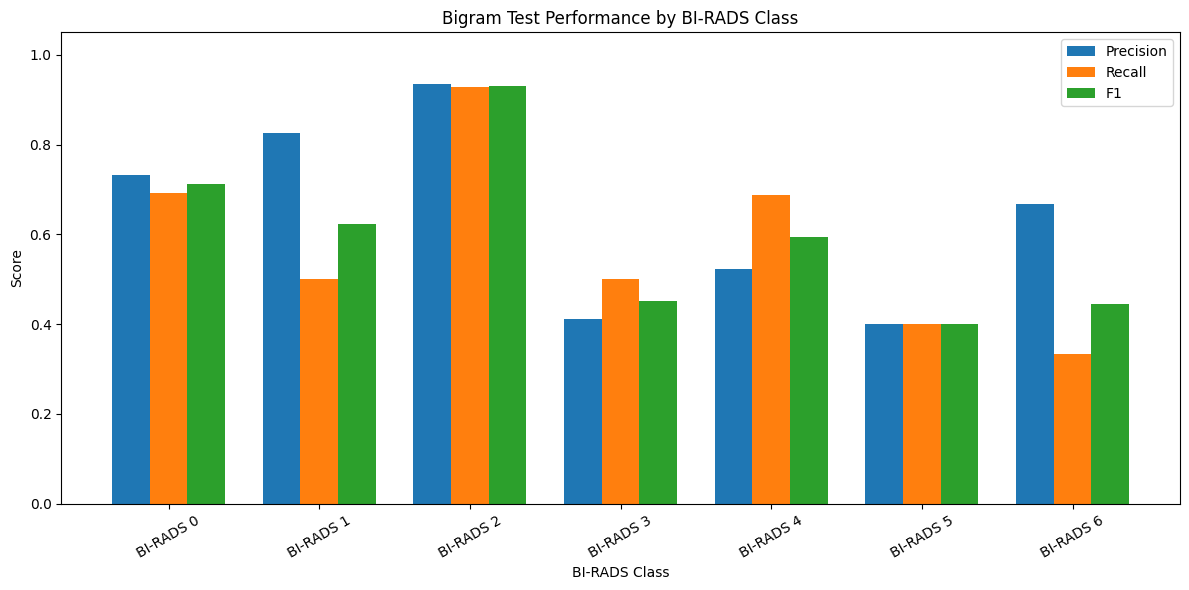

In [20]:
x = np.arange(len(test_per_class))
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(
    x - width,
    test_per_class["Precision"],
    width,
    label="Precision"
)

plt.bar(
    x,
    test_per_class["Recall"],
    width,
    label="Recall"
)

plt.bar(
    x + width,
    test_per_class["F1"],
    width,
    label="F1"
)

plt.xticks(
    x,
    test_per_class["Class"],
    rotation=30
)

plt.ylabel("Score")
plt.xlabel("BI-RADS Class")
plt.title("Bigram Test Performance by BI-RADS Class")
plt.ylim(0, 1.05)
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "bigram_test_per_class_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
cm_val = pd.read_csv(
    CM_DIR / "validation_bigram_confusion_matrix.csv",
    index_col=0
).values

print(cm_val)

[[  19   19    0    0    0    0]
 [   3 1023   56    4    0    1]
 [   0   37   55    7    0    1]
 [   0    6    4   19    2    1]
 [   0    0    0    3    1    0]
 [   0    3    0    0    0    4]]


IndexError: index 6 is out of bounds for axis 1 with size 6

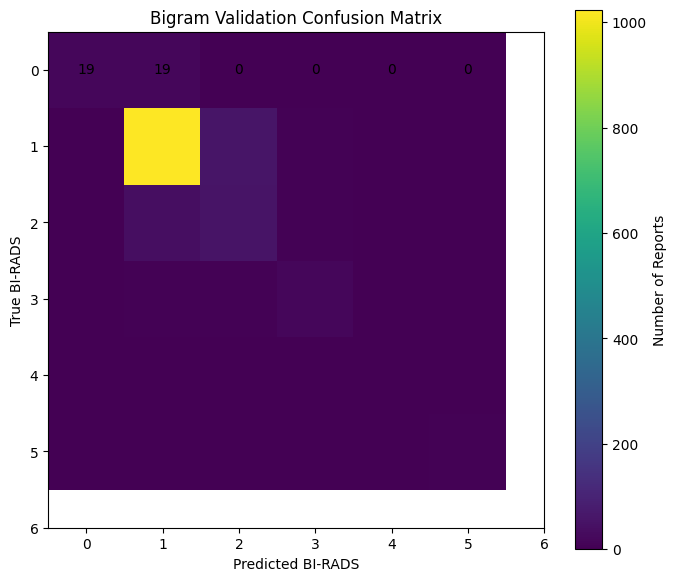

In [22]:
plt.figure(figsize=(8, 7))

plt.imshow(cm_val)

plt.xticks(
    range(7),
    range(7)
)

plt.yticks(
    range(7),
    range(7)
)

plt.xlabel("Predicted BI-RADS")
plt.ylabel("True BI-RADS")
plt.title("Bigram Validation Confusion Matrix")

plt.colorbar(label="Number of Reports")

# Annotate cells
for i in range(7):
    for j in range(7):
        plt.text(
            j,
            i,
            str(cm_val[i, j]),
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "bigram_validation_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

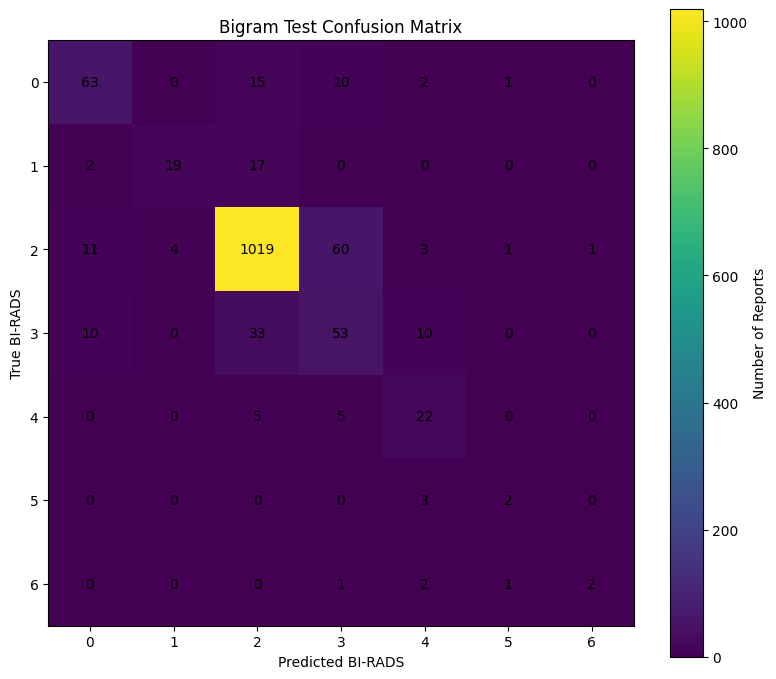

In [23]:
cm_test = pd.read_csv(
    CM_DIR / "test_bigram_confusion_matrix.csv",
    index_col=0
).values

plt.figure(figsize=(8, 7))

plt.imshow(cm_test)

plt.xticks(range(7), range(7))
plt.yticks(range(7), range(7))

plt.xlabel("Predicted BI-RADS")
plt.ylabel("True BI-RADS")
plt.title("Bigram Test Confusion Matrix")

plt.colorbar(label="Number of Reports")

for i in range(7):
    for j in range(7):
        plt.text(
            j,
            i,
            str(cm_test[i, j]),
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "bigram_test_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

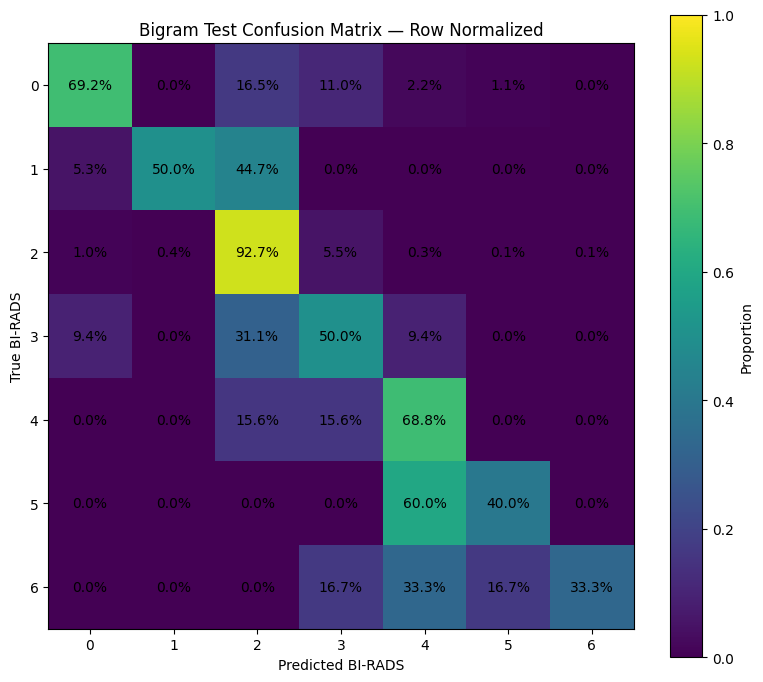

In [24]:
cm_test_norm = pd.read_csv(
    CM_DIR / "test_bigram_confusion_matrix_normalized.csv",
    index_col=0
).values

plt.figure(figsize=(8, 7))

plt.imshow(
    cm_test_norm,
    vmin=0,
    vmax=1
)

plt.xticks(range(7), range(7))
plt.yticks(range(7), range(7))

plt.xlabel("Predicted BI-RADS")
plt.ylabel("True BI-RADS")
plt.title("Bigram Test Confusion Matrix — Row Normalized")

plt.colorbar(label="Proportion")

for i in range(7):
    for j in range(7):
        plt.text(
            j,
            i,
            f"{cm_test_norm[i, j] * 100:.1f}%",
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "bigram_test_confusion_matrix_normalized.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
# ============================================================
# ERROR ANALYSIS
# ============================================================

error_df = test_df[
    [ID_COLUMN, TEXT_COLUMN, LABEL_COLUMN]
].copy()

error_df = error_df.merge(
    test_bigram[
        ["id", "true_label", "predicted_label"]
    ],
    left_on=ID_COLUMN,
    right_on="id",
    how="left"
)

error_df["correct"] = (
    error_df["true_label"] ==
    error_df["predicted_label"]
)

print("Total test reports:", len(error_df))
print("Correct:", error_df["correct"].sum())
print("Incorrect:", (~error_df["correct"]).sum())

Total test reports: 1377
Correct: 1180
Incorrect: 197


In [26]:
misclassified = error_df[
    ~error_df["correct"]
].copy()

misclassified.to_csv(
    ERROR_DIR / "bigram_misclassified_reports.csv",
    index=False
)

print(
    f"Misclassified reports saved: "
    f"{len(misclassified)}"
)

Misclassified reports saved: 197


In [27]:
error_pairs = (
    misclassified
    .groupby(
        ["true_label", "predicted_label"]
    )
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(error_pairs.head(15))

,true_label,predicted_label,count
8,2,3,60
13,3,2,33
5,1,2,17
0,0,2,15
6,2,0,11
14,3,4,10
12,3,0,10
1,0,3,10
16,4,3,5
15,4,2,5


In [29]:
error_pairs.to_csv(
    ERROR_DIR / "most_common_error_pairs.csv",
    index=False
)

# ERROR HEATMAP


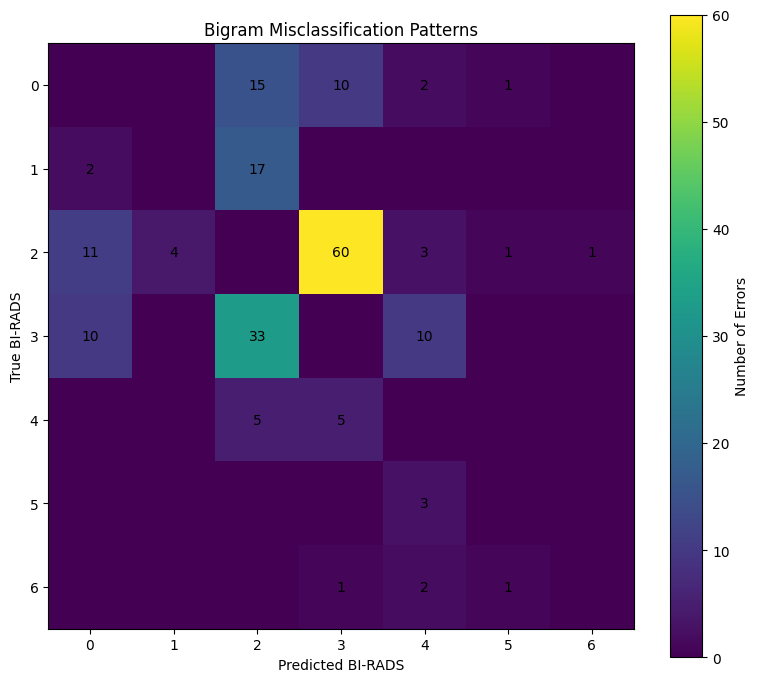

In [30]:
error_matrix = pd.DataFrame(
    0,
    index=range(7),
    columns=range(7)
)

for _, row in error_pairs.iterrows():

    true_label = int(row["true_label"])
    pred_label = int(row["predicted_label"])

    if true_label != pred_label:
        error_matrix.loc[
            true_label,
            pred_label
        ] = row["count"]

plt.figure(figsize=(8, 7))

plt.imshow(error_matrix)

plt.xticks(range(7), range(7))
plt.yticks(range(7), range(7))

plt.xlabel("Predicted BI-RADS")
plt.ylabel("True BI-RADS")
plt.title("Bigram Misclassification Patterns")

plt.colorbar(label="Number of Errors")

for i in range(7):
    for j in range(7):
        if error_matrix.iloc[i, j] > 0:
            plt.text(
                j,
                i,
                str(int(error_matrix.iloc[i, j])),
                ha="center",
                va="center"
            )

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "bigram_error_patterns.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# MAP Score Margin Analysis
If the best class has a MAP score only slightly higher than the second-best class, the model is uncertain.

In [31]:
map_columns = [
    f"map_score_{c}"
    for c in range(7)
]

score_values = test_bigram[map_columns].values

sorted_scores = np.sort(
    score_values,
    axis=1
)

test_bigram["top_map_score"] = sorted_scores[:, -1]
test_bigram["second_map_score"] = sorted_scores[:, -2]

test_bigram["map_margin"] = (
    test_bigram["top_map_score"]
    - test_bigram["second_map_score"]
)

display(
    test_bigram[
        [
            "id",
            "true_label",
            "predicted_label",
            "top_map_score",
            "second_map_score",
            "map_margin"
        ]
    ].head()
)

,id,true_label,predicted_label,top_map_score,second_map_score,map_margin
0,Acc4027,3,2,-65.168240,-72.598015,7.429775
1,Acc9667,2,2,-29.773282,-35.575821,5.802540
2,Acc7054,2,2,-28.077193,-38.565875,10.488682
3,Acc10503,2,2,-65.759219,-83.688048,17.928830
4,Acc7853,2,2,-29.107113,-39.135362,10.028248


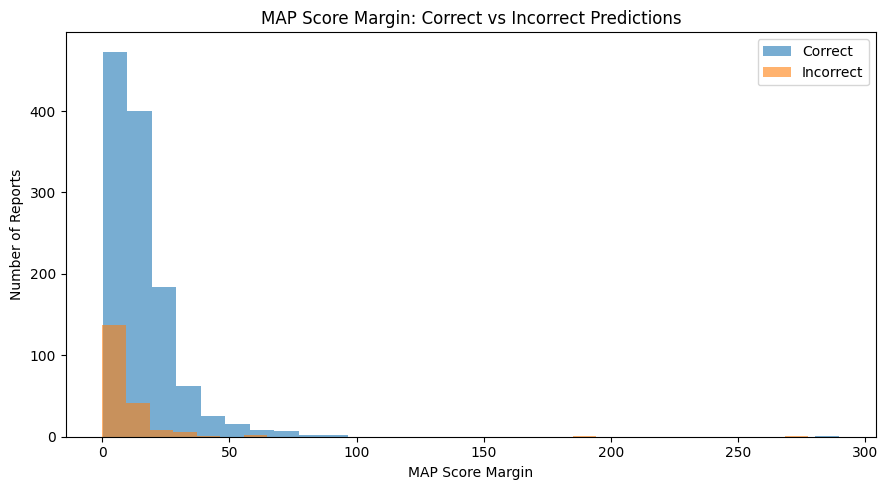

In [32]:
test_bigram["correct"] = (
    test_bigram["true_label"] ==
    test_bigram["predicted_label"]
)

plt.figure(figsize=(9, 5))

plt.hist(
    test_bigram.loc[
        test_bigram["correct"],
        "map_margin"
    ],
    bins=30,
    alpha=0.6,
    label="Correct"
)

plt.hist(
    test_bigram.loc[
        ~test_bigram["correct"],
        "map_margin"
    ],
    bins=30,
    alpha=0.6,
    label="Incorrect"
)

plt.xlabel("MAP Score Margin")
plt.ylabel("Number of Reports")
plt.title("MAP Score Margin: Correct vs Incorrect Predictions")
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "map_margin_correct_vs_incorrect.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Most Uncertain Predictions

In [33]:
uncertain_cases = (
    test_bigram
    .sort_values("map_margin", ascending=True)
    .head(20)
)

uncertain_cases = uncertain_cases.merge(
    test_df[[ID_COLUMN, TEXT_COLUMN]],
    left_on="id",
    right_on=ID_COLUMN,
    how="left"
)

display(
    uncertain_cases[
        [
            "id",
            "true_label",
            "predicted_label",
            "map_margin",
            TEXT_COLUMN
        ]
    ]
)

,id,true_label,predicted_label,map_margin,text
0,Acc1460,0,3,0.069350,clinical indication tracking. findings dense b...
1,Acc7517,2,2,0.108769,clinical indication assessment of focal asymme...
2,Acc10232,3,4,0.122583,right mammographyclinical indication reassessm...
3,Acc19868,2,3,0.177991,clinical indication tracking. findings breasts...
4,Acc3323,2,3,0.185765,clinical indication tracking. findings partial...
5,Acc3275,2,2,0.198308,clinical indication tracking. findings partial...
6,Acc11207,3,0,0.200887,clinical indication reassessment of changes ob...
7,Acc8814,4,4,0.230830,clinical indication tracking. patient presents...
8,Acc3382,2,2,0.315783,clinical indication tracking. findings partial...
9,Acc10774,1,1,0.332357,clinical indication tracking. findings heterog...


In [34]:
uncertain_cases.to_csv(
    EXPLAIN_DIR / "most_uncertain_bigram_predictions.csv",
    index=False
)

In [35]:
from wordcloud import WordCloud

# Generate Class-wise Word Clouds

In [36]:
train_df = pd.read_csv(
    SPLITS_DIR / "train.csv"
)

classes = sorted(
    train_df[LABEL_COLUMN].unique()
)

print("Classes:", classes)

Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


In [37]:
# ============================================================
# CLASS-WISE WORD CLOUDS
# ============================================================

for class_label in classes:

    class_text = " ".join(
        train_df.loc[
            train_df[LABEL_COLUMN] == class_label,
            TEXT_COLUMN
        ].astype(str)
    )

    if not class_text.strip():
        print(
            f"No text available for BI-RADS {class_label}"
        )
        continue

    wordcloud = WordCloud(
        width=1200,
        height=700,
        background_color="white",
        max_words=100,
        collocations=False
    ).generate(class_text)

    plt.figure(figsize=(12, 7))

    plt.imshow(
        wordcloud,
        interpolation="bilinear"
    )

    plt.axis("off")

    plt.title(
        f"Word Cloud — BI-RADS {class_label}",
        fontsize=16
    )

    plt.tight_layout()

    output_path = (
        FIGURES_DIR /
        f"wordcloud_birads_{class_label}.png"
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Saved: {output_path}")

Output hidden; open in https://colab.research.google.com to view.

# Overall Training-Corpus Word Cloud

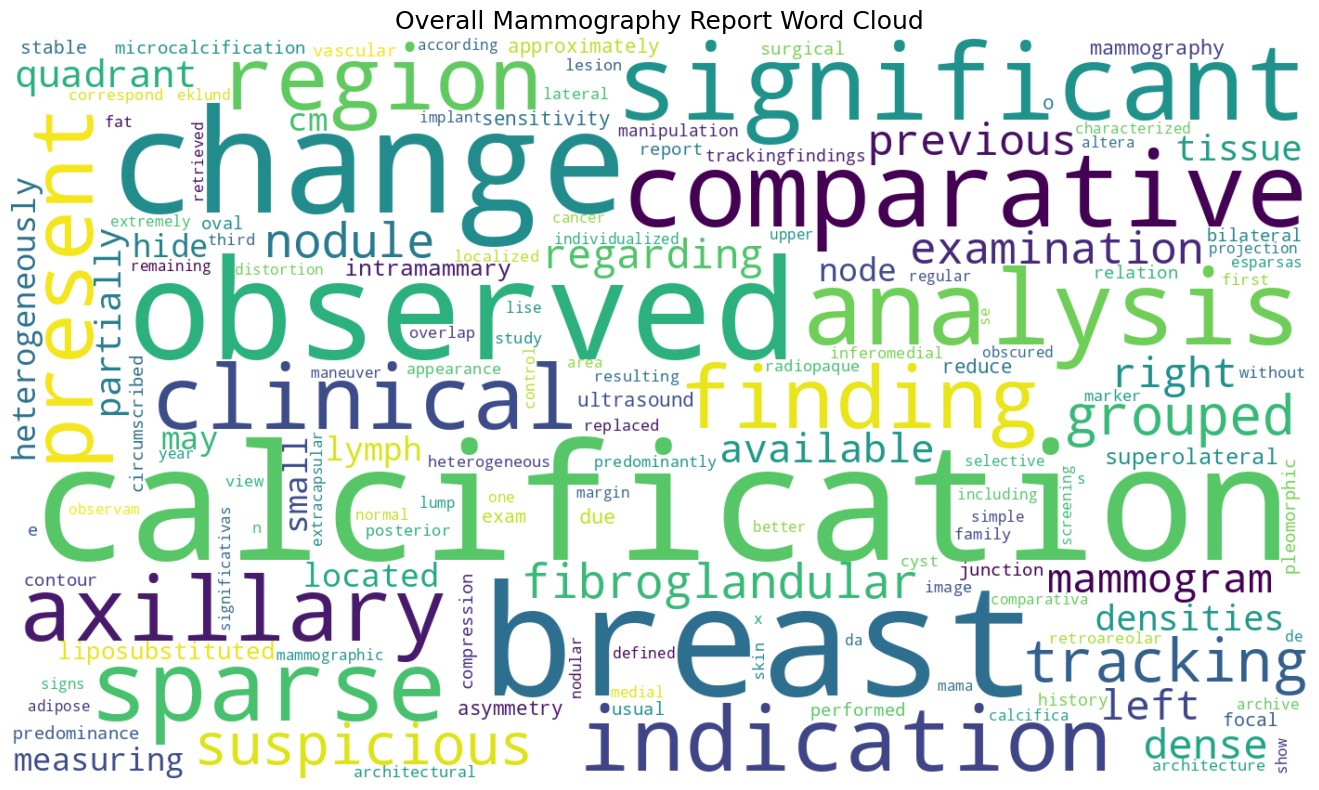

In [38]:
all_training_text = " ".join(
    train_df[TEXT_COLUMN].astype(str)
)

overall_wordcloud = WordCloud(
    width=1400,
    height=800,
    background_color="white",
    max_words=150,
    collocations=False
).generate(all_training_text)

plt.figure(figsize=(14, 8))

plt.imshow(
    overall_wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title(
    "Overall Mammography Report Word Cloud",
    fontsize=18
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "overall_wordcloud.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Word Cloud Interpretation
extract the dominant words

In [39]:
# Extract top words from the overall cloud
top_words = pd.DataFrame(
    overall_wordcloud.words_.items(),
    columns=["Word", "Relative Frequency"]
)

display(
    top_words.head(30)
)

,Word,Relative Frequency
0,calcification,1.000000
1,breast,0.911712
2,change,0.801672
3,observed,0.752879
4,significant,0.739486
5,comparative,0.728312
6,analysis,0.727032
7,sparse,0.668430
8,axillary,0.537064
9,region,0.536637


In [40]:
top_words.to_csv(
    TABLES_DIR / "overall_wordcloud_top_words.csv",
    index=False
)

In [41]:
from collections import Counter

class_top_terms = []

for class_label in classes:

    text = " ".join(
        train_df.loc[
            train_df[LABEL_COLUMN] == class_label,
            TEXT_COLUMN
        ].astype(str)
    )

    words = text.split()

    counts = Counter(words)

    for word, count in counts.most_common(20):

        class_top_terms.append({
            "BI-RADS": class_label,
            "Word": word,
            "Frequency": count
        })

class_top_terms_df = pd.DataFrame(
    class_top_terms
)

display(class_top_terms_df)

,BI-RADS,Word,Frequency
0,0,the,1967
1,0,of,859
2,0,not,697
3,0,comparative,677
4,0,analysis,676
...,...,...,...
135,6,indication,27
136,6,a,26
137,6,findings,26
138,6,and,24


In [42]:
class_top_terms_df.to_csv(
    TABLES_DIR / "class_specific_top_terms.csv",
    index=False
)

# N-gram Model Explainability

In [43]:
# Select the most uncertain test report
example = (
    test_bigram
    .sort_values("map_margin")
    .iloc[0]
)

example_id = example["id"]

score_profile = pd.DataFrame({
    "BI-RADS Class": range(7),
    "MAP Score": [
        example[f"map_score_{c}"]
        for c in range(7)
    ]
})

display(score_profile)

,BI-RADS Class,MAP Score
0,0,-59.358741
1,1,-137.398976
2,2,-60.661949
3,3,-59.289392
4,4,-92.885221
5,5,-139.355458
6,6,-136.705043


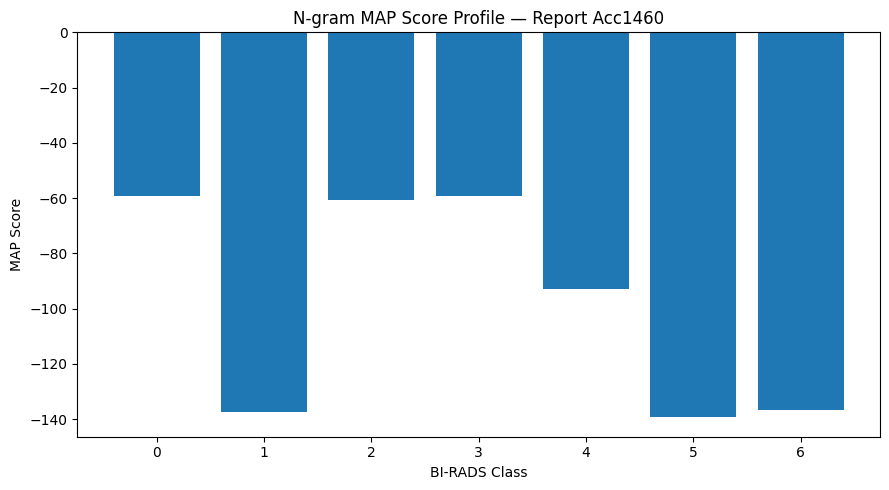

In [44]:
plt.figure(figsize=(9, 5))

plt.bar(
    score_profile["BI-RADS Class"].astype(str),
    score_profile["MAP Score"]
)

plt.xlabel("BI-RADS Class")
plt.ylabel("MAP Score")
plt.title(
    f"N-gram MAP Score Profile — Report {example_id}"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "example_map_score_profile.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:
margin_summary = (
    test_bigram
    .groupby("correct")["map_margin"]
    .agg(
        ["count", "mean", "median", "std", "min", "max"]
    )
)

display(margin_summary)

,count,mean,median,std,min,max
correct,,,,,,
False,197,10.334070,5.467203,24.760404,0.069350,277.449312
True,1180,15.482206,11.721009,14.909081,0.108769,289.731995


In [46]:
margin_summary.to_csv(
    TABLES_DIR / "map_margin_correctness_summary.csv"
)

# Error Rate by MAP-Margin Quartile

In [47]:
test_bigram["margin_quartile"] = pd.qcut(
    test_bigram["map_margin"],
    q=4,
    duplicates="drop"
)

margin_error_analysis = (
    test_bigram
    .groupby("margin_quartile", observed=True)
    .agg(
        samples=("correct", "size"),
        errors=("correct", lambda x: (~x).sum()),
        error_rate=("correct", lambda x: (~x).mean()),
        mean_margin=("map_margin", "mean")
    )
    .reset_index()
)

display(margin_error_analysis)

,margin_quartile,samples,errors,error_rate,mean_margin
0,"(0.0683, 6.612]",346,108,0.312139,3.439123
1,"(6.612, 10.984]",343,38,0.110787,8.634159
2,"(10.984, 18.804]",344,32,0.093023,14.221255
3,"(18.804, 289.732]",344,19,0.055233,32.736193


# Visualize Margin vs Error Rate

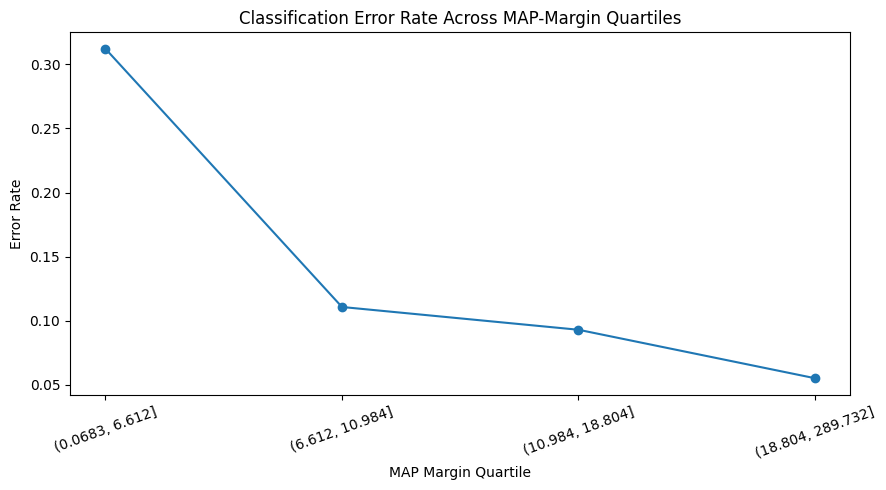

In [49]:
plt.figure(figsize=(9, 5))

plt.plot(
    margin_error_analysis["margin_quartile"].astype(str),
    margin_error_analysis["error_rate"],
    marker="o"
)

plt.xlabel("MAP Margin Quartile")
plt.ylabel("Error Rate")
plt.title("Classification Error Rate Across MAP-Margin Quartiles")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "map_margin_vs_error_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# N-gram Error Analysis by True Class

In [50]:
class_error_analysis = (
    test_bigram
    .groupby("true_label")
    .agg(
        samples=("correct", "size"),
        errors=("correct", lambda x: (~x).sum()),
        error_rate=("correct", lambda x: (~x).mean())
    )
    .reset_index()
)

display(class_error_analysis)

,true_label,samples,errors,error_rate
0,0,91,28,0.307692
1,1,38,19,0.500000
2,2,1099,80,0.072793
3,3,106,53,0.500000
4,4,32,10,0.312500
5,5,5,3,0.600000
6,6,6,4,0.666667


# Class-wise Error Rate

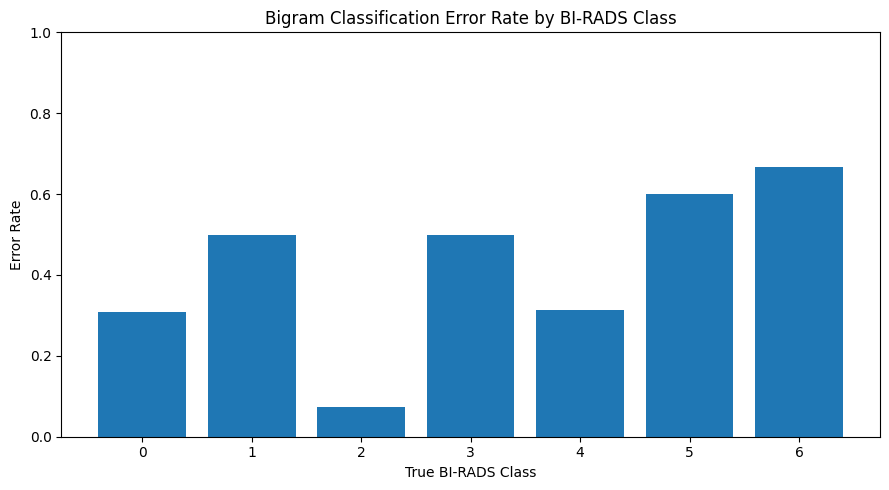

In [51]:
plt.figure(figsize=(9, 5))

plt.bar(
    class_error_analysis["true_label"].astype(str),
    class_error_analysis["error_rate"]
)

plt.xlabel("True BI-RADS Class")
plt.ylabel("Error Rate")
plt.title("Bigram Classification Error Rate by BI-RADS Class")
plt.ylim(0, 1)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "bigram_error_rate_by_class.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# SUMMARY TABLE

In [52]:
paper_summary = validation_results[
    [
        "Model",
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1",
        "Inference Time (s)"
    ]
].copy()

paper_summary.columns = [
    "N-gram",
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Weighted F1",
    "Inference Time (s)"
]

display(
    paper_summary.style.format({
        "Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}",
        "Weighted F1": "{:.4f}",
        "Inference Time (s)": "{:.2f}"
    })
)

,N-gram,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Inference Time (s)
0,Unigram,0.7691,0.3943,0.4335,0.3838,0.7841,0.86
1,Bigram,0.8526,0.6263,0.5633,0.5847,0.8519,3.24
2,Trigram,0.8475,0.6142,0.5397,0.5521,0.8438,7.47


In [53]:
paper_summary.to_csv(
    TABLES_DIR / "paper_ngram_comparison_table.csv",
    index=False
)

# AUTOMATICALLY SELECTING BEST MODEL

In [57]:
best_row = validation_results.loc[
    validation_results["Macro F1"].idxmax()
]

print("Best N-gram according to validation Macro-F1:")
print(f"Model: {best_row['Model']}")
print(f"Order: {best_row['Order']}")
print(f"Macro-F1: {best_row['Macro F1']:.4f}")

Best N-gram according to validation Macro-F1:
Model: Bigram
Order: 2
Macro-F1: 0.5847


In [58]:
final_test_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1"
    ],
    "Bigram Test Score": [
        test_metrics.loc[0, "Accuracy"],
        test_metrics.loc[0, "Macro Precision"],
        test_metrics.loc[0, "Macro Recall"],
        test_metrics.loc[0, "Macro F1"],
        test_metrics.loc[0, "Weighted F1"]
    ]
})

display(
    final_test_summary.style.format({
        "Bigram Test Score": "{:.4f}"
    })
)

,Metric,Bigram Test Score
0,Accuracy,0.8569
1,Macro Precision,0.6422
2,Macro Recall,0.5772
3,Macro F1,0.5938
4,Weighted F1,0.8596


# EVALUATION MANIFEST

In [59]:
evaluation_manifest = {
    "purpose": "N-gram evaluation, visualization and explainability",
    "models_evaluated": [
        "Unigram",
        "Bigram",
        "Trigram"
    ],
    "primary_metric": "Macro F1",
    "final_selected_model": str(best_row["Model"]),
    "final_test_model": "Bigram",
    "outputs": {
        "figures": str(FIGURES_DIR),
        "tables": str(TABLES_DIR),
        "error_analysis": str(ERROR_DIR),
        "explainability": str(EXPLAIN_DIR)
    }
}

with open(
    EVAL_DIR / "evaluation_manifest.json",
    "w"
) as f:
    json.dump(
        evaluation_manifest,
        f,
        indent=4
    )

print("Evaluation manifest saved.")

Evaluation manifest saved.


In [60]:
print("=" * 60)
print("N-GRAM EVALUATION & ANALYSIS COMPLETE")
print("=" * 60)

print("\n✓ Existing validation predictions analyzed")
print("✓ Existing test predictions analyzed")
print("✓ Unigram vs Bigram vs Trigram comparison")
print("✓ Accuracy / Precision / Recall / Macro-F1 / Weighted-F1")
print("✓ Per-class F1 comparison")
print("✓ Validation confusion matrix")
print("✓ Test confusion matrix")
print("✓ Normalized confusion matrix")
print("✓ Misclassification analysis")
print("✓ Most common error pairs")
print("✓ MAP-score margin analysis")
print("✓ Uncertain prediction analysis")
print("✓ BI-RADS class-wise error analysis")
print("✓ Overall word cloud")
print("✓ Class-wise word clouds")
print("✓ Class-specific top terms")
print("✓ N-gram MAP-score explainability")
print("✓ Research-paper tables and figures")

print("\nNo N-gram model was retrained.")
print("No N-gram predictions were regenerated.")
print("Existing results from Notebook 04 were reused.")

N-GRAM EVALUATION & ANALYSIS COMPLETE

✓ Existing validation predictions analyzed
✓ Existing test predictions analyzed
✓ Unigram vs Bigram vs Trigram comparison
✓ Accuracy / Precision / Recall / Macro-F1 / Weighted-F1
✓ Per-class F1 comparison
✓ Validation confusion matrix
✓ Test confusion matrix
✓ Normalized confusion matrix
✓ Misclassification analysis
✓ Most common error pairs
✓ MAP-score margin analysis
✓ Uncertain prediction analysis
✓ BI-RADS class-wise error analysis
✓ Overall word cloud
✓ Class-wise word clouds
✓ Class-specific top terms
✓ N-gram MAP-score explainability
✓ Research-paper tables and figures

No N-gram model was retrained.
No N-gram predictions were regenerated.
Existing results from Notebook 04 were reused.
